# 1a. Feature Selection for SLDS

**Purpose:** Determine which summary statistics to retain as the SLDS observation space.

**Approach:**
1. Build full feature matrix, audit NaN rates
2. Pooled Spearman correlation → clustered heatmap → redundant groups
3. Within-animal Spearman correlation (removes between-animal variance)
4. PCA — effective dimensionality
5. Early vs Late Wilcoxon — which features significantly change with learning?
6. Select representative features

**Note:** The final feature set is selected by combining quantitative criteria
(low redundancy, high PC loading, significant learning-related change) with
interpretability. Downstream validation (whether the selected features produce
better SLDS state separation than alternatives) is assessed in notebook 5.

In [1]:
%matplotlib inline
from shared_setup import *

import seaborn as sns
from scipy.stats import spearmanr, wilcoxon
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

from behav_utils.analysis.session_features import get_feature_columns

## 1. Load Data

In [2]:
experiment, load_info = load_data()
SHIFT_SESSION = load_info.get('shift_session', None)

Loaded 12 animals, 433 total sessions
Loaded 12 animals, 433 sessions from CSV


## 2. Build Full Feature Matrix

In [3]:
all_animals = experiment.get_animals(min_sessions=5)
pooled_df = build_feature_matrix_multi(all_animals, stage=STAGE)
print(f"Feature matrix: {pooled_df.shape[0]} sessions × {pooled_df.shape[1]} columns")
print(f"Animals: {pooled_df['animal_id'].nunique()}")
print(f"Sessions per animal: {pooled_df.groupby('animal_id').size().values}")

Feature matrix: 410 sessions × 148 columns
Animals: 12
Sessions per animal: [49  4 56 41 41 41 41 32 31 31 13 30]


## 3. NaN Audit & Feature Filtering

In [4]:
feature_cols = get_feature_columns(pooled_df)
print(f"Numeric feature columns: {len(feature_cols)}")

nan_counts = pooled_df[feature_cols].isna().sum().sort_values(ascending=False)
nan_pct = (nan_counts / len(pooled_df) * 100).round(1)
nan_df = pd.DataFrame({'feature': nan_counts.index, 'n_nan': nan_counts.values,
                        'pct_nan': nan_pct.values})

print("\nNaN prevalence:")
print(nan_df[nan_df['n_nan'] > 0].to_string(index=False))
if nan_df['n_nan'].sum() == 0:
    print("  (all features fully populated)")

NAN_THRESHOLD = 0.20
high_nan = nan_df[nan_df['pct_nan'] > NAN_THRESHOLD * 100]['feature'].tolist()
if high_nan:
    print(f"\nExcluding (>{NAN_THRESHOLD*100:.0f}% NaN): {high_nan}")

clean_features = [f for f in feature_cols if f not in high_nan]

# Also remove near-zero-variance
variances = pooled_df[clean_features].var()
near_zero = variances[variances < 1e-10].index.tolist()
if near_zero:
    print(f"Removing near-zero-variance: {near_zero}")
    clean_features = [f for f in clean_features if f not in near_zero]

print(f"\nRetained features: {len(clean_features)}")

Numeric feature columns: 131

NaN prevalence:
               feature  n_nan  pct_nan
                 slope     37      9.0
                   pse     37      9.0
      cond_lapse_low_3      3      0.7
          cond_slope_2      3      0.7
      cond_lapse_low_4      3      0.7
          cond_slope_4      3      0.7
            cond_pse_4      3      0.7
     cond_lapse_high_3      3      0.7
          cond_slope_3      3      0.7
            cond_pse_3      3      0.7
     cond_lapse_high_2      3      0.7
      cond_lapse_low_2      3      0.7
     cond_lapse_high_1      3      0.7
            cond_pse_2      3      0.7
            cond_pse_5      3      0.7
      cond_lapse_low_1      3      0.7
          cond_slope_1      3      0.7
            cond_pse_1      3      0.7
     cond_lapse_high_0      3      0.7
      cond_lapse_low_0      3      0.7
          cond_slope_0      3      0.7
            cond_pse_0      3      0.7
     cond_lapse_high_4      3      0.7
          cond_slo

In [5]:
feat_summary = pooled_df[clean_features].describe().T
feat_summary['cv'] = (feat_summary['std'] / feat_summary['mean'].abs()).round(3)
print("Feature distributions:")
print(feat_summary[['count', 'mean', 'std', 'min', '50%', 'max', 'cv']].round(4).to_string())

Feature distributions:
                        count      mean        std        min       50%        max      cv
accuracy                410.0    0.6821     0.1079     0.0978    0.6904     0.8846   0.158
pse                     373.0    0.1323     0.3116    -0.9854    0.1358     0.9900   2.356
slope                   373.0    0.5075     0.4671     0.0100    0.3935     4.4979   0.920
lapse_low               410.0    0.1588     0.1366     0.0000    0.1216     0.5000   0.860
lapse_high              410.0    0.1306     0.1477     0.0000    0.0793     0.5000   1.131
psychometric_gof        410.0    0.8030     0.3611    -3.0700    0.9475     0.9984   0.450
recency                 410.0    0.1776     0.1744    -0.2082    0.1519     0.5900   0.982
stimulus_recency        410.0    0.1776     0.1744    -0.2082    0.1519     0.5900   0.982
win_stay                410.0    0.1035     0.1382    -0.2341    0.0945     0.4774   1.335
lose_shift              410.0    0.4184     0.1379     0.0122    0.

---
## 4. Pooled Spearman Correlation

Pairwise Spearman across all sessions (pooled). Clusters features by similarity.

In [6]:
corr_df = pooled_df[clean_features].dropna()
print(f"Complete cases: {len(corr_df)} / {len(pooled_df)}")

corr_matrix, _ = spearmanr(corr_df)
corr_matrix = pd.DataFrame(corr_matrix, index=clean_features, columns=clean_features).fillna(0)

dist_matrix = 1 - np.abs(corr_matrix.values)
np.fill_diagonal(dist_matrix, 0)
dist_matrix = np.clip((dist_matrix + dist_matrix.T) / 2, 0, None)
condensed = squareform(dist_matrix)
Z = linkage(condensed, method='average')

Complete cases: 373 / 410


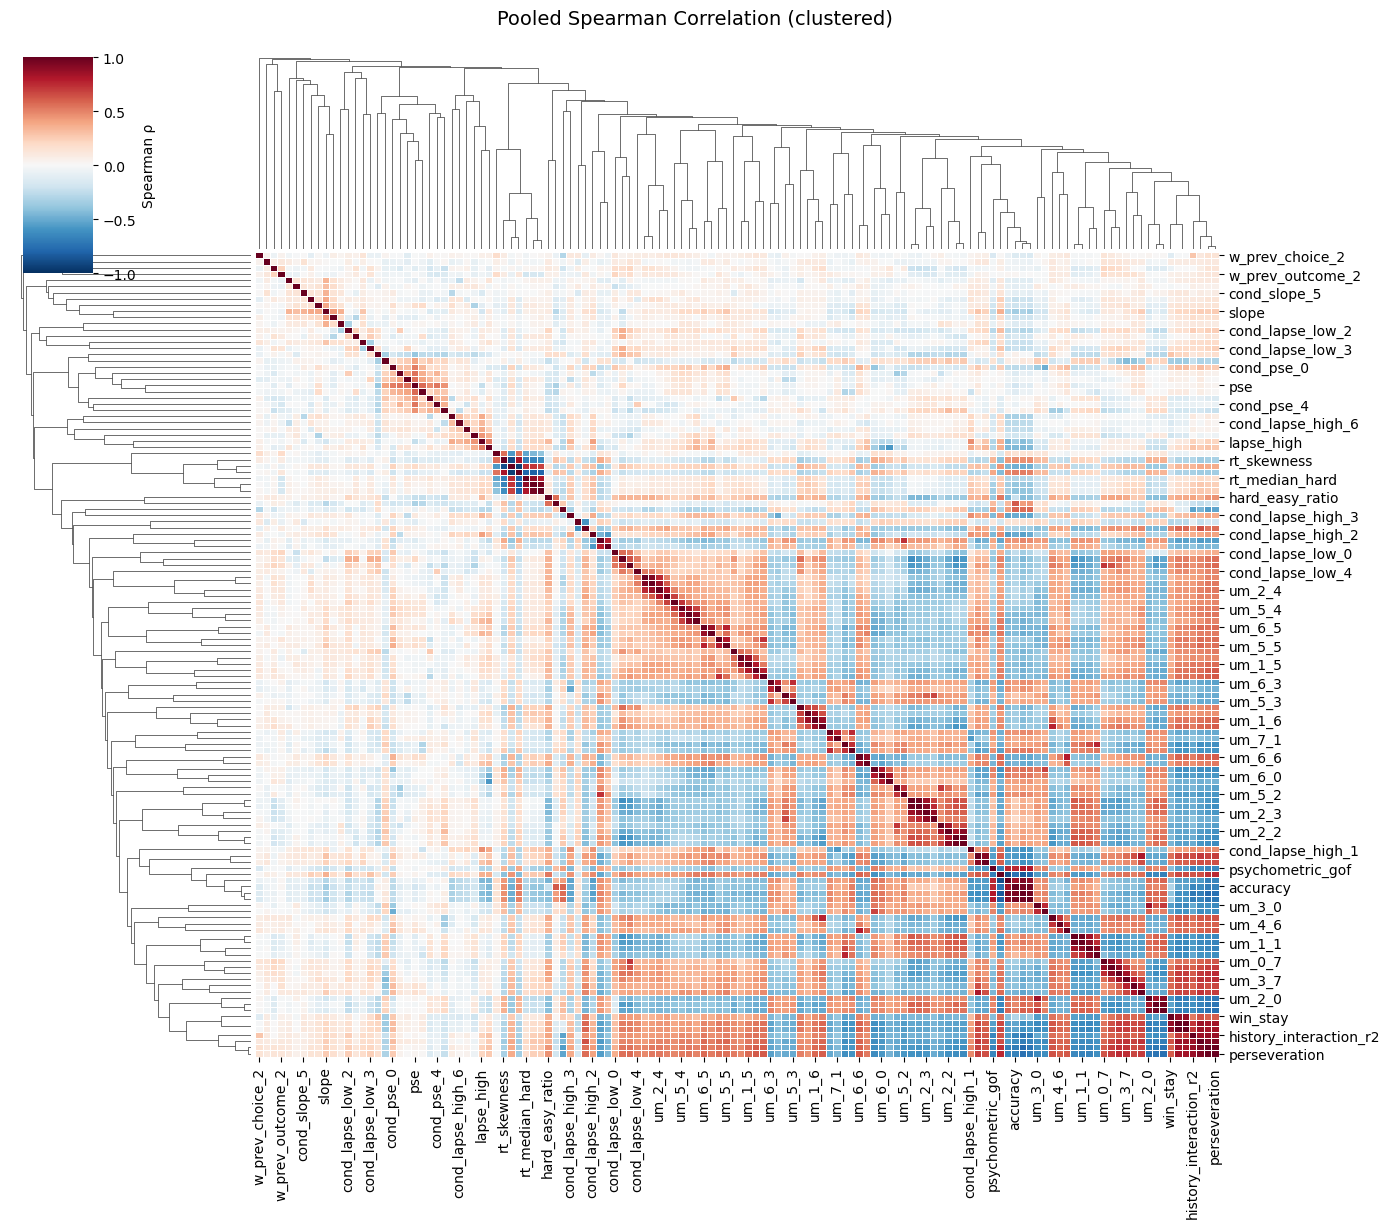

In [7]:
g = sns.clustermap(
    corr_matrix, row_linkage=Z, col_linkage=Z,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    figsize=(14, 12), linewidths=0.5, annot=False,
    cbar_kws={'label': 'Spearman ρ'},
)
g.fig.suptitle('Pooled Spearman Correlation (clustered)', y=1.02, fontsize=14)
plt.show()

In [8]:
CORR_THRESHOLD = 0.70
clusters = fcluster(Z, t=1 - CORR_THRESHOLD, criterion='distance')
cluster_df = pd.DataFrame({'feature': clean_features, 'cluster': clusters}).sort_values('cluster')

print(f"Clusters (|ρ| > {CORR_THRESHOLD}): {cluster_df['cluster'].nunique()}\n")
for c in sorted(cluster_df['cluster'].unique()):
    members = cluster_df[cluster_df['cluster'] == c]['feature'].tolist()
    if len(members) > 1:
        sub = corr_matrix.loc[members, members]
        triu = sub.values[np.triu_indices(len(members), k=1)]
        print(f"Cluster {c} (n={len(members)}, mean |ρ|={np.mean(np.abs(triu)):.2f}):")
    else:
        print(f"Cluster {c} (singleton):")
    for m in members:
        print(f"  - {m}")
    print()

Clusters (|ρ| > 0.7): 80

Cluster 1 (singleton):
  - w_prev_outcome_1

Cluster 2 (singleton):
  - w_prev_outcome_2

Cluster 3 (singleton):
  - w_prev_outcome_3

Cluster 4 (singleton):
  - slope

Cluster 5 (singleton):
  - cond_slope_1

Cluster 6 (singleton):
  - cond_slope_7

Cluster 7 (singleton):
  - cond_slope_4

Cluster 8 (singleton):
  - cond_slope_5

Cluster 9 (singleton):
  - cond_slope_0

Cluster 10 (singleton):
  - cond_slope_6

Cluster 11 (singleton):
  - cond_slope_2

Cluster 12 (singleton):
  - cond_lapse_low_2

Cluster 13 (singleton):
  - cond_slope_3

Cluster 14 (singleton):
  - cond_lapse_low_3

Cluster 15 (singleton):
  - cond_lapse_low_1

Cluster 16 (singleton):
  - side_bias

Cluster 17 (singleton):
  - cond_pse_7

Cluster 18 (singleton):
  - pse

Cluster 19 (singleton):
  - cond_pse_1

Cluster 20 (singleton):
  - cond_pse_3

Cluster 21 (singleton):
  - cond_pse_2

Cluster 22 (singleton):
  - cond_pse_0

Cluster 23 (singleton):
  - cond_pse_4

Cluster 24 (singleton):


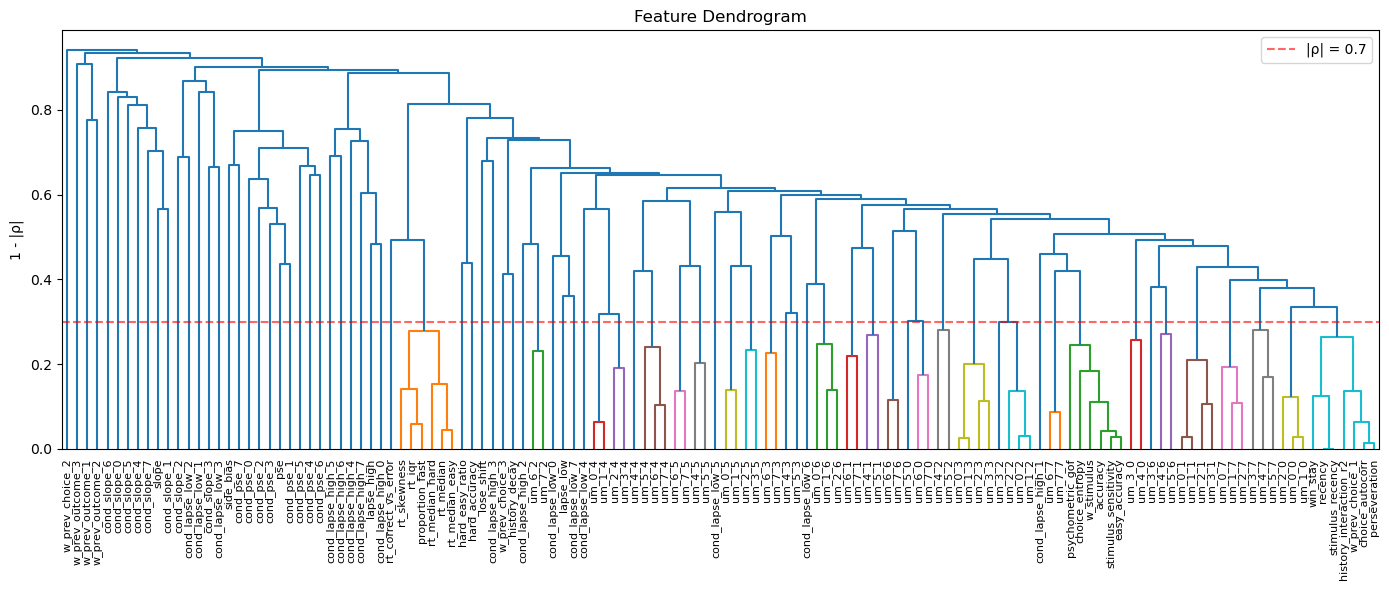

In [9]:
# Dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=clean_features, leaf_rotation=90, leaf_font_size=8,
           ax=ax, color_threshold=1 - CORR_THRESHOLD)
ax.axhline(1 - CORR_THRESHOLD, color='red', linestyle='--', alpha=0.6,
           label=f'|ρ| = {CORR_THRESHOLD}')
ax.set_ylabel('1 - |ρ|')
ax.set_title('Feature Dendrogram')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Within-Animal Correlation

The pooled correlation conflates between-animal differences with within-animal
learning dynamics. Within-animal correlation strips out the between-animal
variance and asks: which features co-vary *within* each animal's learning
trajectory?

This is computed per-animal then averaged, giving a cleaner picture of
redundancy that's relevant to SLDS state definition.

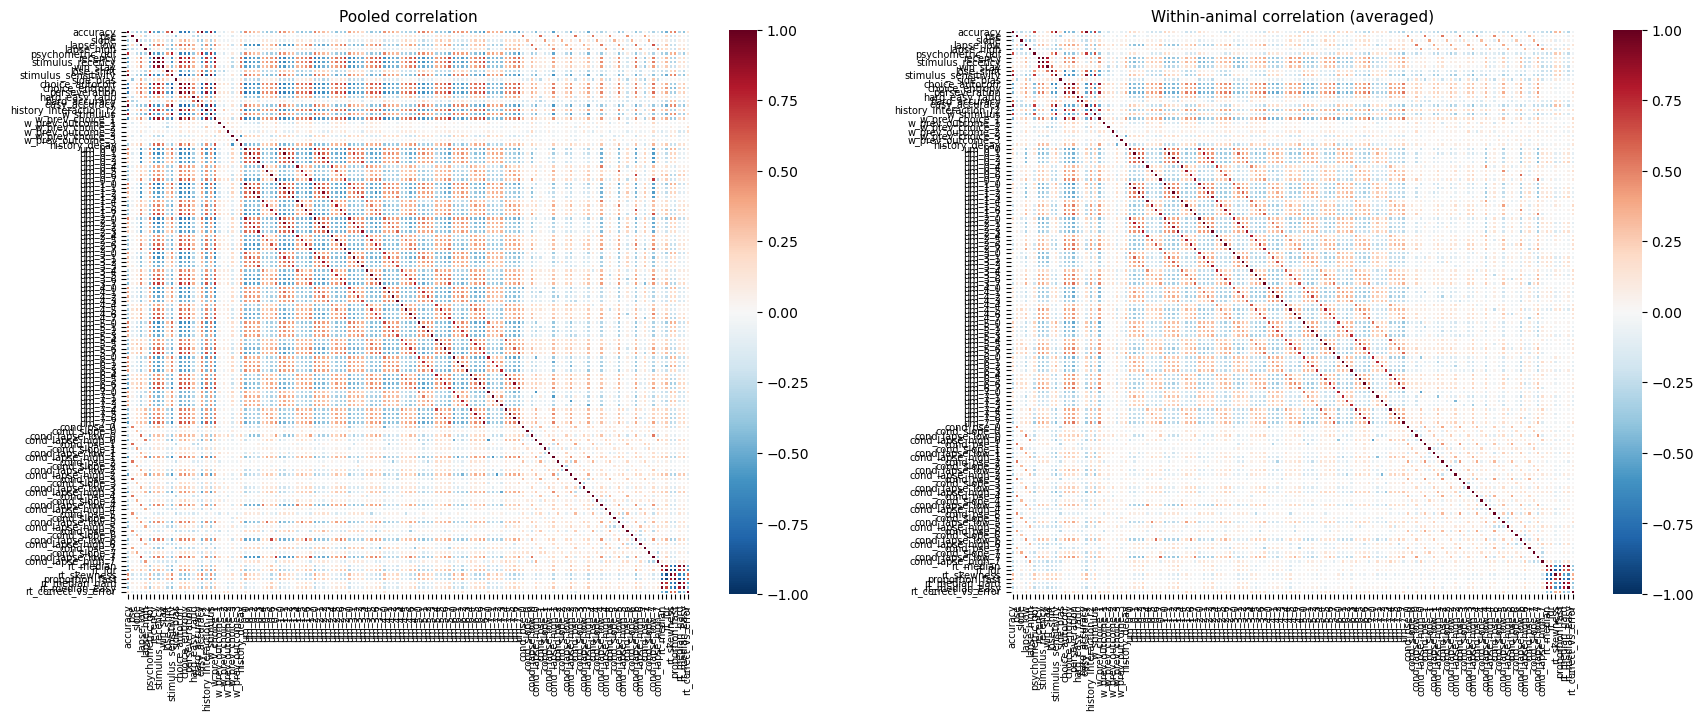

In [10]:
MIN_SESSIONS = 8

animal_ids = pooled_df['animal_id'].unique()
corr_within_all = []

for aid in animal_ids:
    adf = pooled_df[pooled_df['animal_id'] == aid][clean_features]
    if len(adf) < MIN_SESSIONS:
        continue
    corr_a = adf.corr(method='spearman')
    if not corr_a.isnull().all().all():
        corr_within_all.append(corr_a.values)

if corr_within_all:
    corr_within_mean = np.nanmean(corr_within_all, axis=0)
    corr_within_df = pd.DataFrame(corr_within_mean,
                                   index=clean_features, columns=clean_features)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=axes[0], square=True, linewidths=0.3,
                xticklabels=True, yticklabels=True)
    axes[0].set_title('Pooled correlation', fontsize=11)
    axes[0].tick_params(labelsize=7)

    sns.heatmap(corr_within_df, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                ax=axes[1], square=True, linewidths=0.3,
                xticklabels=True, yticklabels=True)
    axes[1].set_title('Within-animal correlation (averaged)', fontsize=11)
    axes[1].tick_params(labelsize=7)

    plt.tight_layout()
    plt.show()
else:
    print("Not enough animals with sufficient sessions for within-animal correlation.")

### 5.1 Within-Animal Correlation with Session Index

Which features consistently track learning (monotonic change with session number)?
Spearman ρ(feature, session_index) computed per animal, then summarised.

Spearman ρ(feature, session_index) — averaged across animals:
               feature  mean_rho  median_rho  std_rho  n_animals  frac_positive  frac_negative
         perseveration    -0.482      -0.518    0.282         11          0.091          0.909
       choice_autocorr    -0.454      -0.528    0.281         11          0.091          0.909
       w_prev_choice_1    -0.435      -0.596    0.256         11          0.091          0.909
      cond_lapse_low_7    -0.410      -0.460    0.232         11          0.091          0.909
         easy_accuracy     0.408       0.341    0.311         11          0.909          0.091
                um_1_7    -0.406      -0.418    0.176         11          0.000          1.000
history_interaction_r2    -0.404      -0.419    0.314         11          0.091          0.909
             lapse_low    -0.403      -0.360    0.221         11          0.091          0.909
                um_7_7    -0.397      -0.454    0.180         11          0.000    

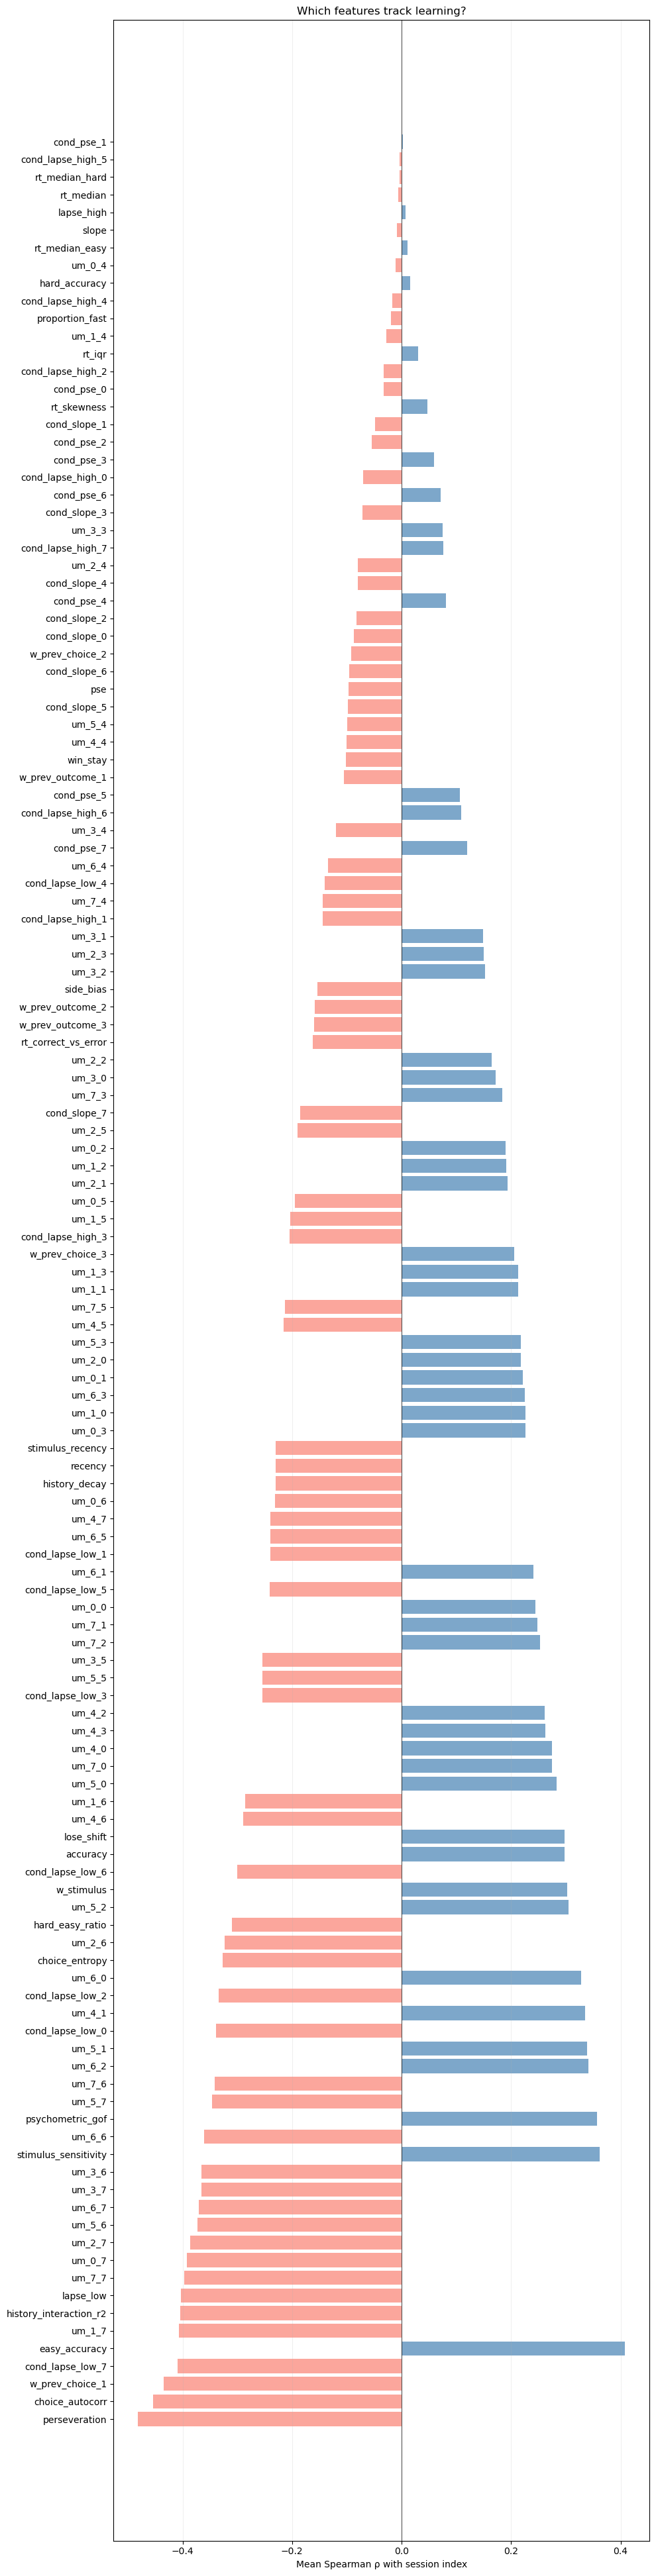

In [11]:
rho_results = {feat: [] for feat in clean_features}

for aid in animal_ids:
    adf = pooled_df[pooled_df['animal_id'] == aid].sort_values('session_idx')
    if len(adf) < MIN_SESSIONS:
        continue

    sess_idx = adf['session_idx'].values

    for feat in clean_features:
        vals = adf[feat].values.astype(float)
        valid = ~np.isnan(vals)
        if valid.sum() < MIN_SESSIONS:
            continue
        rho, p = spearmanr(sess_idx[valid], vals[valid])
        rho_results[feat].append(rho)

# Summarise
rows = []
for feat in clean_features:
    rhos = rho_results[feat]
    if len(rhos) < 3:
        continue
    arr = np.array(rhos)
    rows.append({
        'feature': feat,
        'mean_rho': np.mean(arr),
        'median_rho': np.median(arr),
        'std_rho': np.std(arr),
        'n_animals': len(arr),
        'frac_positive': np.mean(arr > 0),
        'frac_negative': np.mean(arr < 0),
    })

rho_df = pd.DataFrame(rows).sort_values('mean_rho', key=abs, ascending=False)

print("Spearman ρ(feature, session_index) — averaged across animals:")
print(rho_df.round(3).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, max(4, len(rho_df) * 0.3)))
colours = ['steelblue' if r > 0 else 'salmon' for r in rho_df['mean_rho']]
ax.barh(rho_df['feature'], rho_df['mean_rho'], color=colours, alpha=0.7)
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Mean Spearman ρ with session index')
ax.set_title('Which features track learning?')
ax.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

---
## 6. PCA — Effective Dimensionality

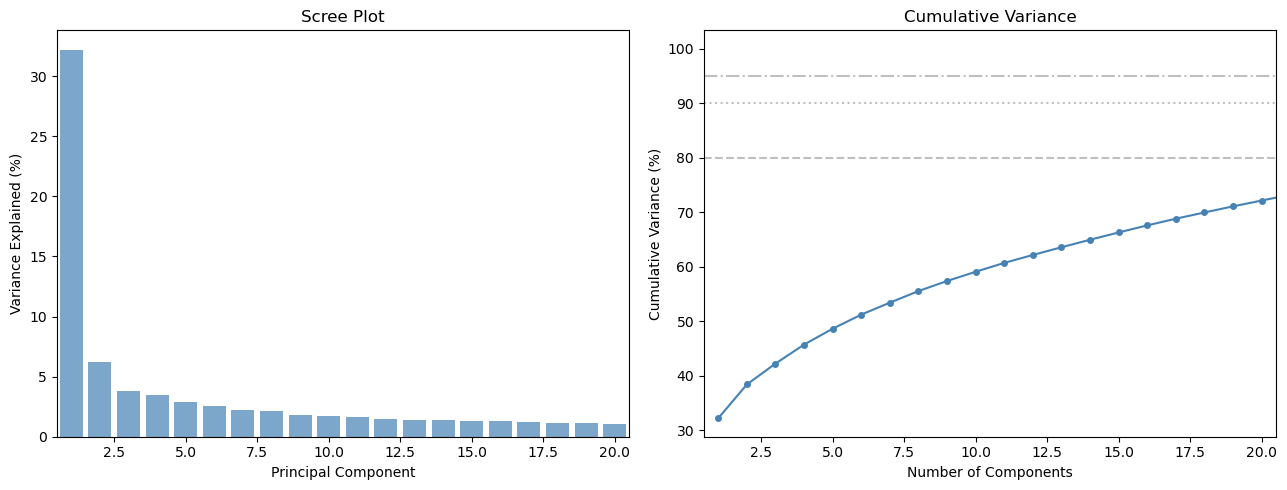

80% variance → 29 components
85% variance → 36 components
90% variance → 47 components
95% variance → 63 components


In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(corr_df)
pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained) + 1), explained * 100, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0.5, min(20.5, len(explained) + 0.5))

axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, 'o-',
             color='steelblue', markersize=4)
for thresh, style in [(0.80, '--'), (0.90, ':'), (0.95, '-.')]:
    axes[1].axhline(thresh * 100, color='grey', linestyle=style, alpha=0.5)
    n_comp = np.argmax(cumulative >= thresh) + 1
    axes[1].annotate(f'{thresh*100:.0f}%: {n_comp} PCs',
                     xy=(n_comp + 0.3, thresh * 100 - 2), fontsize=8)

axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Variance')
axes[1].set_xlim(0.5, min(20.5, len(cumulative) + 0.5))

plt.tight_layout()
plt.show()

for thresh in [0.80, 0.85, 0.90, 0.95]:
    n_comp = np.argmax(cumulative >= thresh) + 1
    print(f"{thresh*100:.0f}% variance → {n_comp} components")

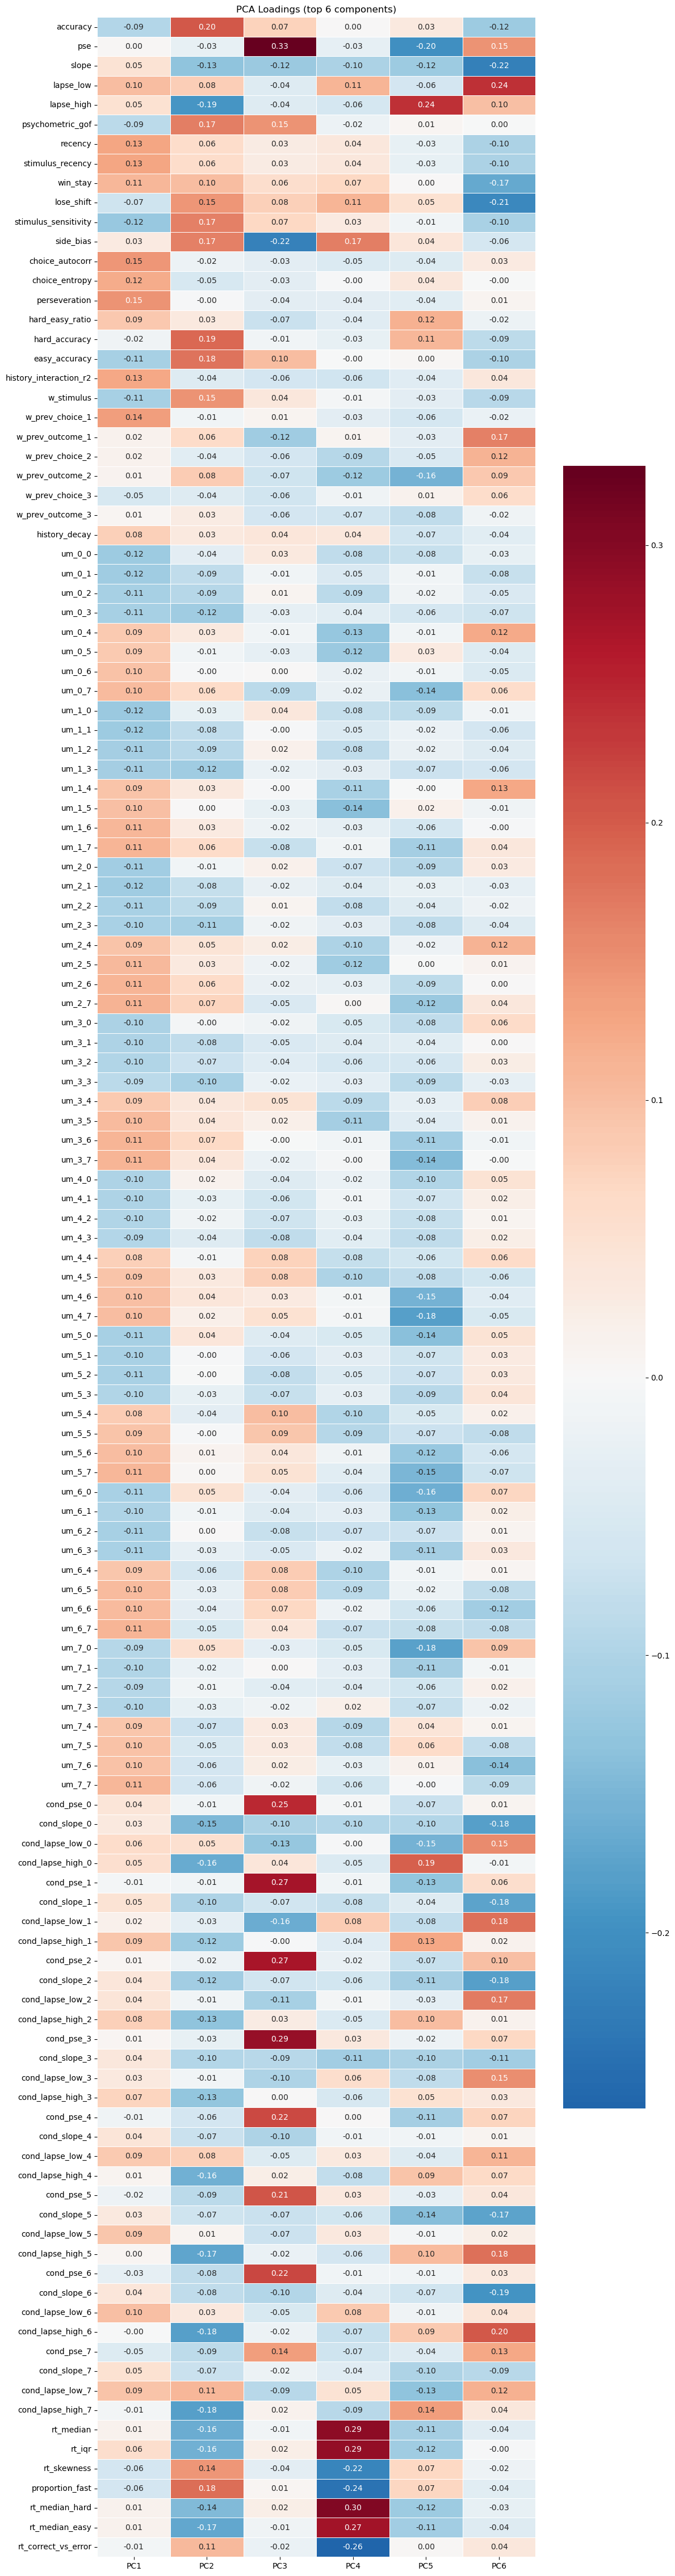

Top 3 features per component:

PC1 (32.2% var):
  + perseveration: 0.147
  + choice_autocorr: 0.145
  + w_prev_choice_1: 0.138

PC2 (6.2% var):
  + accuracy: 0.203
  - lapse_high: 0.192
  + hard_accuracy: 0.189

PC3 (3.8% var):
  + pse: 0.329
  + cond_pse_3: 0.286
  + cond_pse_1: 0.273

PC4 (3.5% var):
  + rt_median_hard: 0.301
  + rt_median: 0.292
  + rt_iqr: 0.289



In [13]:
# Loadings
n_show = min(6, len(explained))
loadings = pd.DataFrame(pca.components_[:n_show].T,
                         index=clean_features,
                         columns=[f'PC{i+1}' for i in range(n_show)])

fig, ax = plt.subplots(figsize=(12, max(6, len(clean_features) * 0.35)))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            ax=ax, linewidths=0.5)
ax.set_title(f'PCA Loadings (top {n_show} components)')
plt.tight_layout()
plt.show()

print("Top 3 features per component:\n")
for pc_idx in range(min(4, n_show)):
    pc = f'PC{pc_idx + 1}'
    abs_l = loadings[pc].abs().sort_values(ascending=False)
    print(f"{pc} ({explained[pc_idx]*100:.1f}% var):")
    for feat, val in abs_l.head(3).items():
        sign = '+' if loadings.loc[feat, pc] > 0 else '-'
        print(f"  {sign} {feat}: {val:.3f}")
    print()

---
## 7. Early vs Late Validation (Wilcoxon)

Which features significantly change between early (first N sessions) and late
(last N sessions) within each animal? This is a paired within-animal test — the
most direct evidence that a feature carries learning-phase information.

In [14]:
N_WINDOW = 5

early_late_results = []

for feat in clean_features:
    early_vals = []
    late_vals = []

    for aid in animal_ids:
        adf = pooled_df[pooled_df['animal_id'] == aid].sort_values('session_idx')
        if len(adf) < 2 * N_WINDOW:
            continue

        early = adf[feat].iloc[:N_WINDOW].mean()
        late = adf[feat].iloc[-N_WINDOW:].mean()

        if np.isnan(early) or np.isnan(late):
            continue

        early_vals.append(early)
        late_vals.append(late)

    if len(early_vals) < 5:
        continue

    early_arr = np.array(early_vals)
    late_arr = np.array(late_vals)

    try:
        stat, p = wilcoxon(early_arr, late_arr)
    except ValueError:
        stat, p = np.nan, np.nan

    early_late_results.append({
        'feature': feat,
        'early_mean': np.mean(early_arr),
        'late_mean': np.mean(late_arr),
        'delta': np.mean(late_arr) - np.mean(early_arr),
        'wilcoxon_stat': stat,
        'wilcoxon_p': p,
        'n_animals': len(early_vals),
    })

el_df = pd.DataFrame(early_late_results).sort_values('wilcoxon_p')
print(f"Early (first {N_WINDOW}) vs Late (last {N_WINDOW}) — paired Wilcoxon:")
print(el_df.round(4).to_string(index=False))

Early (first 5) vs Late (last 5) — paired Wilcoxon:
               feature  early_mean  late_mean     delta  wilcoxon_stat  wilcoxon_p  n_animals
                um_0_7      0.3053     0.1085   -0.1968            0.0      0.0010         11
                um_6_6      0.1847     0.0411   -0.1436            0.0      0.0010         11
      cond_lapse_low_7      0.3668     0.1663   -0.2005            0.0      0.0010         11
                um_5_2     -0.2693    -0.0673    0.2020            0.0      0.0010         11
      cond_lapse_low_0      0.2442     0.0537   -0.1905            0.0      0.0010         11
      cond_lapse_low_2      0.2127     0.0455   -0.1672            0.0      0.0010         11
             lapse_low      0.2781     0.1099   -0.1682            0.0      0.0010         11
      cond_lapse_low_1      0.2226     0.0672   -0.1554            1.0      0.0020         11
      cond_lapse_low_3      0.1873     0.0538   -0.1335            1.0      0.0020         11
        

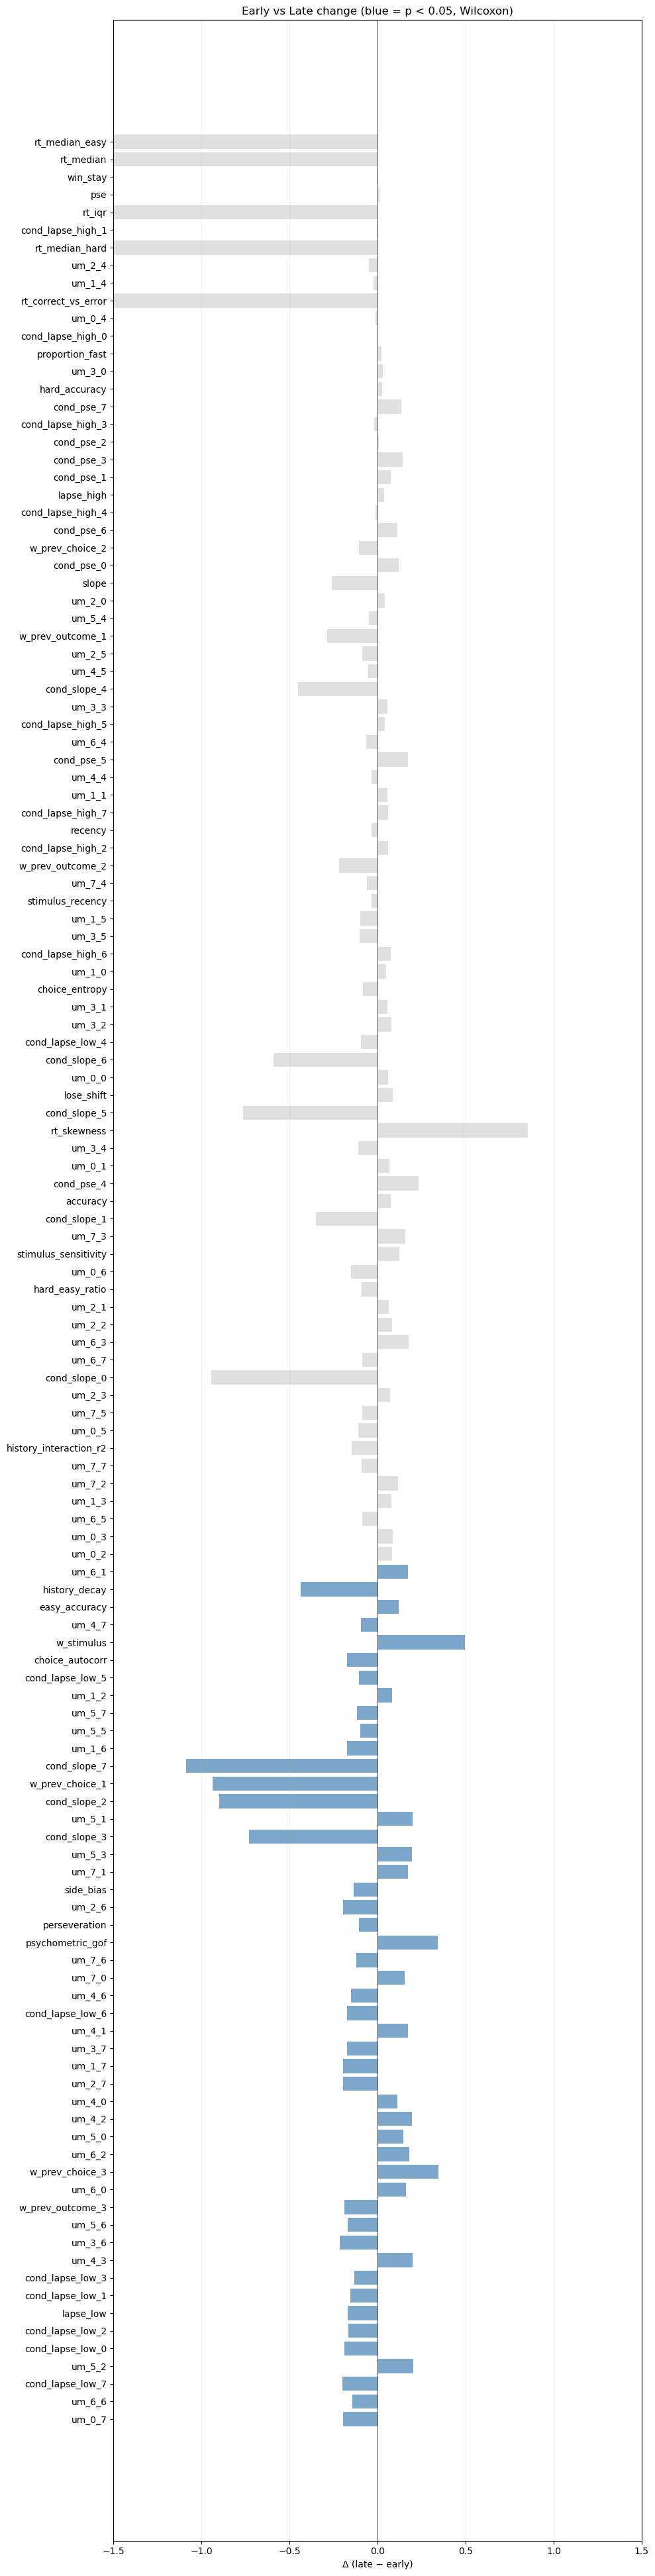


49 / 130 features significantly change early → late (p < 0.05)


In [15]:
# Visualise: effect sizes
sig = el_df[el_df['wilcoxon_p'] < 0.05].copy()
nonsig = el_df[el_df['wilcoxon_p'] >= 0.05].copy()

fig, ax = plt.subplots(figsize=(10, max(4, len(el_df) * 0.3)))

# Plot all features
for _, row in el_df.iterrows():
    colour = 'steelblue' if row['wilcoxon_p'] < 0.05 else 'lightgrey'
    ax.barh(row['feature'], row['delta'], color=colour, alpha=0.7)

ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('Δ (late − early)')
ax.set_title(f'Early vs Late change (blue = p < 0.05, Wilcoxon)')
ax.grid(True, alpha=0.2, axis='x')
ax.set_xbound(-1.5, 1.5)
plt.tight_layout()
plt.show()

n_sig = len(sig)
print(f"\n{n_sig} / {len(el_df)} features significantly change early → late (p < 0.05)")

---
## 8. Feature Selection: Recommendations

### Criteria:
1. **One per correlated cluster** — most interpretable representative
2. **Covers top PC loadings** — spans main variance axes
3. **Significant early→late change** — carries learning-phase information
4. **Proposal-relevant** — distinguishes model-updating from inference
5. **Low NaN rate**

### Suggested core set:

| Feature | Rationale |
|---------|-----------|
| `accuracy` | Overall performance |
| `pse` | Boundary estimate / adaptation |
| `slope` | Discrimination quality |
| `recency` | Category-based serial dependence |
| `choice_entropy` | Choice variability |
| `win_stay` | Reward sensitivity |
| `side_bias` | Motor bias (confound) |
| `lapse_low` | Attentional engagement |

### Likely exclusions:
- `hard_accuracy`, `easy_accuracy` → redundant with `accuracy` + `slope`
- `stimulus_recency` → correlated with `recency` under uniform
- `recency_divergence` → near-zero pre-shift
- `sd_*` → expensive and noisy
- Binned stats → high-dimensional

In [16]:
SELECTED_FEATURES = [
    'accuracy', 'pse', 'slope', 'recency',
    'choice_entropy', 'win_stay', 'side_bias', 'lapse_low',
]

available = [f for f in SELECTED_FEATURES if f in clean_features]
missing = [f for f in SELECTED_FEATURES if f not in clean_features]

print(f"Selected features ({len(available)} available):")
for f in available:
    # Annotate with cluster and early-late p-value
    cl = cluster_df[cluster_df['feature'] == f]['cluster'].values
    cl_str = f"cluster {cl[0]}" if len(cl) > 0 else "?"
    el_row = el_df[el_df['feature'] == f]
    p_str = f"p={el_row['wilcoxon_p'].values[0]:.4f}" if len(el_row) > 0 else "?"
    print(f"  ✓ {f:<20} ({cl_str}, early-late {p_str})")

if missing:
    print(f"\nNot in data: {missing}")

Selected features (8 available):
  ✓ accuracy             (cluster 70, early-late p=0.1016)
  ✓ pse                  (cluster 18, early-late p=0.9658)
  ✓ slope                (cluster 4, early-late p=0.4131)
  ✓ recency              (cluster 79, early-late p=0.2402)
  ✓ choice_entropy       (cluster 70, early-late p=0.1748)
  ✓ win_stay             (cluster 79, early-late p=0.9658)
  ✓ side_bias            (cluster 16, early-late p=0.0137)
  ✓ lapse_low            (cluster 42, early-late p=0.0010)


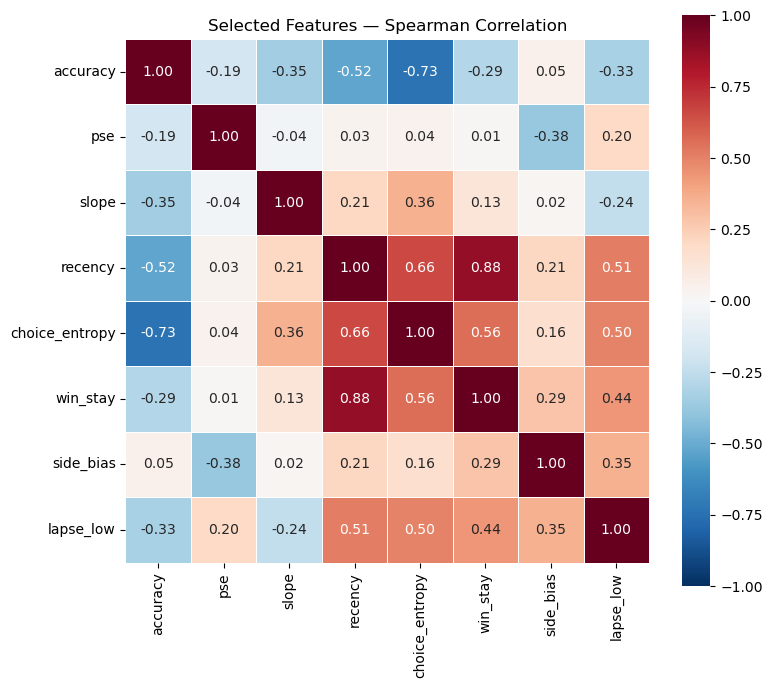

⚠ High correlation: accuracy ↔ choice_entropy: ρ = -0.73
⚠ High correlation: recency ↔ win_stay: ρ = 0.88


In [17]:
# Correlation among selected features — check for residual redundancy
if len(available) >= 2:
    selected_corr = corr_df[available].corr(method='spearman')

    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(selected_corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', ax=ax, square=True, linewidths=0.5)
    ax.set_title('Selected Features — Spearman Correlation')
    plt.tight_layout()
    plt.show()

    flagged = False
    for i in range(len(available)):
        for j in range(i+1, len(available)):
            rho = selected_corr.iloc[i, j]
            if abs(rho) > 0.70:
                print(f"⚠ High correlation: {available[i]} ↔ {available[j]}: ρ = {rho:.2f}")
                flagged = True
    if not flagged:
        print("No high correlations (|ρ| > 0.70) among selected features.")

---
## 9. Export & Next Steps

**Next:**
1. Run on real data — cluster structure and PCA will shift
2. Revisit after post-manipulation data exists
3. Feed `SELECTED_FEATURES` into SLDS fitting
4. Iterate if SLDS state recovery is poor

In [18]:
print("SLDS_FEATURES =", available)
print()
print("# Usage:")
print("# df = build_feature_matrix(animal, stage='Full_Task_Cont')")
print("# X = df[SLDS_FEATURES].values")

SLDS_FEATURES = ['accuracy', 'pse', 'slope', 'recency', 'choice_entropy', 'win_stay', 'side_bias', 'lapse_low']

# Usage:
# df = build_feature_matrix(animal, stage='Full_Task_Cont')
# X = df[SLDS_FEATURES].values
